# 06 — TabNet (PyTorch)

This notebook trains and evaluates the TabNet independently from the other models.

TabNet (Arik & Pfister, 2019) uses sequential attentive steps with sparse feature selection
instead of a fixed architecture.  Each step learns a soft mask over the input features,
focusing on a different subset at every pass.

| Component | ResFNN | TabNet |
|---|---|---|
| Architecture | Residual blocks (256→128→64) | Sequential attentive steps (N_steps=4) |
| Feature selection | All features equally | Sparse attention mask per step |
| Normalisation | Batch Normalisation | Batch Normalisation (momentum=0.02) |
| Activation | ReLU | Gated Linear Unit (GLU) + Sparsemax |
| Optimiser | AdamW (wd=1e-2) | AdamW (wd=1e-5) |
| LR schedule | ReduceLROnPlateau (patience=5) | ReduceLROnPlateau (patience=7) |
| Loss | BCEWithLogitsLoss + pos_weight | BCEWithLogitsLoss + pos_weight + sparsity |
| Interpretability | None | Per-step feature importance maps |
| Patience | 15 epochs | 20 epochs |
| Max epochs | 200 | 200 |

Results are appended to `outputs/results/metrics.csv`.  
Plots are saved to `outputs/figures/models/`.

## 0 · Imports

In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

'''Self Modules'''
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.models import split_data, get_X_y
from src.tabnet import train_tabnet, TabNetWrapper
from src.evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve
from config import FEATURE_SETS, FEATURE_CONFIG, FIGURES_MODELS, PLOT_DPI

## 1 · Load & Split

Split is done on the **raw** DataFrame before preprocessing.  
This prevents any data leakage from imputation or encoding statistics.

In [3]:
df_raw = load_data()

df_train_raw, df_test_raw = split_data(df_raw, test_seasons=[2022, 2023])

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet
[split_data] Train seasons : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
[split_data] Test  seasons : [np.int32(2022), np.int32(2023)]
[split_data] Train rows    : 286,892
[split_data] Test  rows    : 99,099


## 2 · TabNet Feature Set Loop

Train the TabNet on all feature sets and collect metrics.  
Training curve, confusion matrix, and ROC curve are saved for every feature set.

In [4]:
# preprocess the largest feature set once; reuse column subsets to avoid redundant work.
LARGEST_FS = max(FEATURE_SETS, key=lambda k: len(FEATURE_SETS[k]))
_df_train_full = preprocess(df_train_raw, feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)
_df_test_full  = preprocess(df_test_raw,  feature_set=FEATURE_SETS[LARGEST_FS], feature_config=FEATURE_CONFIG)

# test and train alignment
_df_test_full = _df_test_full.reindex(columns=_df_train_full.columns, fill_value=0)


                              PREPROCESSING REPORT                              

INPUT:
   Shape: (286892, 372)
   Missing: 38714249 NaNs (36.28%)

OUTPUT:
   Shape: (203362, 122)
   Features (X): 121 columns
   Target (y): 203362 samples
   Missing: 0 NaNs

SELECTED FEATURES IMPUTATION DETAILS:
   Feature Name                   | NaNs Before  | NaNs After  | Filled/Removed
   ----------------------------------------------------------------------
   down                           | 743          | 0           | 743      | dropped (<1% NaNs)      
   ydstogo                        | 0            | 0           | 0        | -                       
   yardline_100                   | 0            | 0           | 0        | -                       
   goal_to_go                     | 0            | 0           | 0        | -                       
   shotgun                        | 0            | 0           | 0        | -                       
   no_huddle                      | 0     

In [5]:
# updated feature sets with encoded column names before loop
FEATURE_SETS_ENCODED = {
    fs_name: [
        c for c in _df_train_full.columns
        if c != "target" and any(c == f or c.startswith(f + "_") for f in fs_cols)
    ]
    for fs_name, fs_cols in FEATURE_SETS.items()
}
FEATURE_SETS_ENCODED

{'mini': ['down',
  'ydstogo',
  'shotgun',
  'no_huddle',
  'score_differential',
  'posteam_timeouts_remaining',
  'quarter_seconds_remaining'],
 'comprehensive': ['down',
  'ydstogo',
  'yardline_100',
  'goal_to_go',
  'shotgun',
  'no_huddle',
  'score_differential',
  'defteam_score',
  'posteam_timeouts_remaining',
  'defteam_timeouts_remaining',
  'game_seconds_remaining',
  'half_seconds_remaining',
  'qtr',
  'ep',
  'wp',
  'total_line',
  'roof_dome',
  'roof_open',
  'roof_outdoors',
  'drive_start_transition_BLOCKED_FG,_DOWNS',
  'drive_start_transition_BLOCKED_PUNT',
  'drive_start_transition_BLOCKED_PUNT,_DOWNS',
  'drive_start_transition_DOWNS',
  'drive_start_transition_FUMBLE',
  'drive_start_transition_INTERCEPTION',
  'drive_start_transition_KICKOFF',
  'drive_start_transition_MISSED_FG',
  'drive_start_transition_MUFFED_KICKOFF',
  'drive_start_transition_MUFFED_PUNT',
  'drive_start_transition_ONSIDE_KICK',
  'drive_start_transition_OWN_KICKOFF',
  'drive_start_t


 TabNet | Feature set: mini  (7 features)
  Epoch  10 | train_loss: 0.4551 | val_loss: 0.4541 | lr: 2.00e-03 | no_improve: 1/20
  Epoch  20 | train_loss: 0.4542 | val_loss: 0.4538 | lr: 2.00e-03 | no_improve: 2/20
  Epoch  30 | train_loss: 0.4532 | val_loss: 0.4516 | lr: 2.00e-03 | no_improve: 0/20
  Epoch  40 | train_loss: 0.4516 | val_loss: 0.4525 | lr: 1.00e-03 | no_improve: 10/20
  Epoch  50 | train_loss: 0.4503 | val_loss: 0.4524 | lr: 5.00e-04 | no_improve: 20/20

[train_tabnet] Early stopping at epoch 50.
[train_tabnet] Training complete. Best val_loss: 0.4516
[evaluate_model] Metrics saved in C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\outputs\results\metrics.csv

[evaluate_model] TabNet | feature_set=mini
  Accuracy  : 0.7089
  F1        : 0.7101
  ROC-AUC   : 0.7776
  Precision : 0.7124
  Recall    : 0.7089



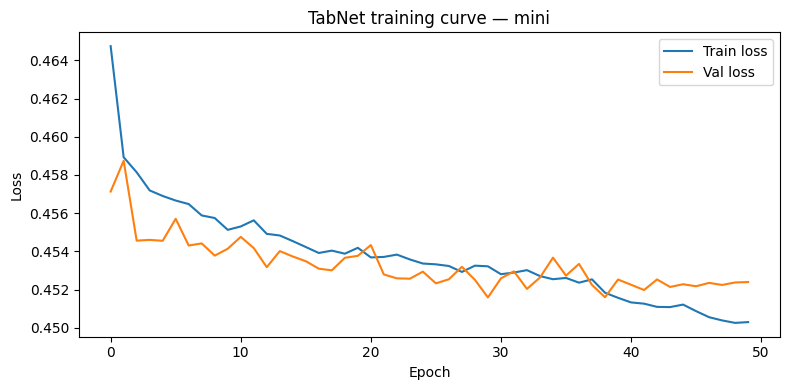

TypeError: plot_confusion_matrix() got an unexpected keyword argument 'title'

In [ ]:
all_metrics = []

for fs_name, fs_cols in FEATURE_SETS_ENCODED.items():

    print(f"\n{'='*55}")
    print(f" TabNet | Feature set: {fs_name}  ({len(fs_cols)} features)")
    print(f"{'='*55}")

    # subset preprocessed data to the current feature set
    df_train = _df_train_full[fs_cols + ["target"]]
    df_test  = _df_test_full[fs_cols + ["target"]]

    X_train, y_train = get_X_y(df_train)
    X_test,  y_test  = get_X_y(df_test)

    # train
    model, history, scaler = train_tabnet(
        X_train, y_train,
        val_split=0.1,
        epochs=200,
        batch_size=512,
        lr=2e-3,
        patience=20,
        n_d=32,
        n_a=32,
        n_steps=4,
        gamma=1.5,
        lambda_sparse=1e-4,
    )

    wrapper = TabNetWrapper(model, scaler)

    # evaluate
    metrics = evaluate_model(wrapper, X_test, y_test, "TabNet", fs_name)
    all_metrics.append(metrics)

    # --- training curve ---
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train_loss"], label="Train loss")
    ax.plot(history["val_loss"],   label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"TabNet training curve — {fs_name}")
    ax.legend()
    fig.tight_layout()
    #fig.savefig(FIGURES_MODELS / f"tabnet_training_curve_{fs_name}.png", dpi=PLOT_DPI)
    plt.show()

    # --- confusion matrix ---
    #fig_cm = plot_confusion_matrix(wrapper, X_test, y_test, "TabNet", fs_name)
    #fig_cm.savefig(FIGURES_MODELS / f"tabnet_confusion_matrix_{fs_name}.png", dpi=PLOT_DPI)
    #plt.show()

    # --- ROC curve ---
    #fig_roc = plot_roc_curve(wrapper, X_test, y_test, "TabNet", fs_name)
    #fig_roc.savefig(FIGURES_MODELS / f"tabnet_roc_curve_{fs_name}.png", dpi=PLOT_DPI)
    #plt.show()

print("\n=== Summary ===")
for m in all_metrics:
    print(m)

## 3 · Feature Importance (maxi feature set)

TabNet computes sparse attention masks at each step.  
Summing these masks across all steps gives a natural feature importance score —
higher values indicate features the model relied on more heavily.

In [ ]:
# retrain on maxi to get the final model for importance analysis
fs_name  = "maxi"
fs_cols  = FEATURE_SETS_ENCODED[fs_name]

df_train = _df_train_full[fs_cols + ["target"]]
X_train, y_train = get_X_y(df_train)

model_maxi, _, scaler_maxi = train_tabnet(
    X_train, y_train,
    val_split=0.1,
    epochs=200,
    batch_size=512,
    lr=2e-3,
    patience=20,
)

# compute importances on the full training set
X_scaled = pd.DataFrame(scaler_maxi.transform(X_train), columns=X_train.columns)
X_tensor = torch.tensor(X_scaled.values, dtype=torch.float32)
importances = model_maxi.get_feature_importances(X_tensor)

importance_df = (
    pd.Series(importances, index=fs_cols)
    .sort_values(ascending=False)
)

# plot top-20
fig, ax = plt.subplots(figsize=(9, 6))
importance_df.head(20).plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Cumulative attention weight")
ax.set_title("TabNet — Top 20 feature importances (maxi)")
fig.tight_layout()
#fig.savefig(FIGURES_MODELS / "tabnet_feature_importance_maxi.png", dpi=PLOT_DPI)
plt.show()

print("\nTop 20 features:")
print(importance_df.head(20).to_string())

  Epoch  10 | train_loss: 0.4427 | val_loss: 0.4428 | lr: 2.00e-03 | no_improve: 2/20
  Epoch  20 | train_loss: 0.4392 | val_loss: 0.4423 | lr: 2.00e-03 | no_improve: 3/20
  Epoch  30 | train_loss: 0.4343 | val_loss: 0.4403 | lr: 1.00e-03 | no_improve: 2/20
  Epoch  40 | train_loss: 0.4306 | val_loss: 0.4404 | lr: 5.00e-04 | no_improve: 4/20
  Epoch  50 | train_loss: 0.4275 | val_loss: 0.4410 | lr: 2.50e-04 | no_improve: 14/20
  Epoch  56 | train_loss: 0.4265 | val_loss: 0.4413 | lr: 1.25e-04 | no_improve: 20/20

[train_tabnet] Early stopping at epoch 56.
[train_tabnet] Training complete. Best val_loss: 0.4391


: 

## 4 · Sanity checks

In [ ]:
# verify no NaNs leaked into training / test splits
print("Train NaNs :", _df_train_full.isna().sum().sum())
print("Test  NaNs :", _df_test_full.isna().sum().sum())
print("Train shape:", _df_train_full.shape)
print("Test  shape:", _df_test_full.shape)
print("Target distribution (train):")
print(_df_train_full["target"].value_counts(normalize=True).round(3))